In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("dt_prepared.csv")

X = df.drop("Target", axis=1)
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=11, stratify=y
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

X_train.head(100).to_csv("ensemble_train_sample.csv", index=False)
X_test.head(100).to_csv("ensemble_test_sample.csv", index=False)

# Display previews
print("\nTrain Data Sample:")
display(X_train.head())

print("\nTest Data Sample:")
display(X_test.head())


Training Set Shape: (56000, 33)
Testing Set Shape: (14000, 33)

Train Data Sample:


,Genetic Markers,Autoantibodies,Family History,Environmental Factors,Insulin Levels,Age,BMI,Physical Activity,Dietary Habits,Blood Pressure,...,Pulmonary Function,Cystic Fibrosis Diagnosis,Steroid Use History,Genetic Testing,Neurological Assessments,Liver Function Tests,Digestive Enzyme Levels,Urine Test,Birth Weight,Early Onset Symptoms
46981,0,0,0,1,23.0,37,27.0,2,1,121,...,78,0,0,1,1,0,44,2,3653,0
53951,1,0,0,0,33.0,14,23.0,0,1,103,...,50,1,0,1,2,0,73,2,3159,0
17370,1,1,1,1,8.0,24,16.0,2,0,91,...,84,0,0,1,2,1,41,3,2558,1
35377,0,0,1,1,11.0,13,15.0,2,1,106,...,78,1,1,0,2,1,55,2,3972,1
4467,1,1,1,0,9.0,10,14.0,1,1,72,...,55,1,1,0,1,1,27,2,1914,1



Test Data Sample:


,Genetic Markers,Autoantibodies,Family History,Environmental Factors,Insulin Levels,Age,BMI,Physical Activity,Dietary Habits,Blood Pressure,...,Pulmonary Function,Cystic Fibrosis Diagnosis,Steroid Use History,Genetic Testing,Neurological Assessments,Liver Function Tests,Digestive Enzyme Levels,Urine Test,Birth Weight,Early Onset Symptoms
4350,1,1,0,0,19.0,39,25.0,2,0,120,...,78,0,0,1,2,0,68,2,3294,1
14665,0,0,1,0,15.0,53,30.0,2,0,126,...,72,0,1,1,2,1,77,2,3898,1
57348,0,1,1,0,16.0,35,31.0,0,1,119,...,81,1,1,0,2,0,72,0,4057,1
65011,1,1,0,0,12.0,21,17.0,0,1,106,...,77,1,0,1,2,1,63,3,2810,0
62793,0,0,1,1,27.0,44,26.0,0,0,140,...,65,0,0,0,2,1,73,1,3548,1


Random Forest Accuracy: 0.8966

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.91      0.95      1093
           1       0.90      0.92      0.91      1069
           2       0.95      0.94      0.94      1044
           3       0.95      0.87      0.91      1111
           4       1.00      1.00      1.00      1082
           5       0.96      1.00      0.98      1075
           6       0.80      0.77      0.78      1096
           7       0.80      0.82      0.81      1055
           8       0.87      0.99      0.93      1089
           9       0.89      0.70      0.78      1079
          10       0.81      1.00      0.90      1064
          11       0.91      0.83      0.87      1080
          12       0.84      0.92      0.88      1063

    accuracy                           0.90     14000
   macro avg       0.90      0.90      0.90     14000
weighted avg       0.90      0.90      0.90     14000



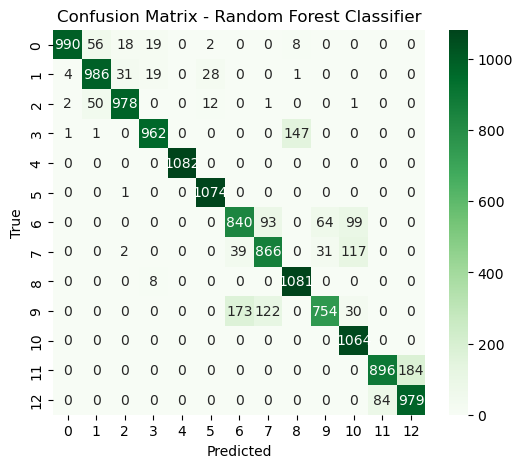

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest Classifier")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
